
# Mixture Model
This notebook contains the code for a simple implementation of the Leaspy Mixture model on synthetic data.
Before implementing the model take a look at the relevant mathematical framework in the user guide.


The following imports are required libraries for numerical computation, data manipulation, and visualization.



In [1]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

import leaspy
from leaspy.io.data import Data, Dataset

This toy example is part of a simulation study, carried out by Sofia Kaisaridi that will be included in
an article to be submitted in a biostatistics journal. The dataset contains 1000 individuals each with 6 visits and 6 scores.



In [2]:
leaspy_root = os.path.dirname(leaspy.__file__)

data_path = os.path.join(leaspy_root, "datasets/data/simulated_data_for_mixture.csv")

all_data = pd.read_csv(data_path, sep=";", decimal=",")
all_data["ID"] = all_data["ID"].ffill()
all_data = all_data.set_index(["ID", "TIME"])
all_data.head()

score_1_normalized  score_2_normalized  score_3_normalized  \
ID     TIME                                                                    
subj_1 50.159062            0.197863            0.057787            0.095305   
       66.713371            0.418290            0.139975            0.021792   
       68.994947            0.397005            0.149633            0.040861   
       73.009543            0.330076            0.127369            0.098300   
       80.948301            0.530554            0.117444            0.159612   

                  score_4_normalized  score_5_normalized  score_6_normalized  
ID     TIME                                                                   
subj_1 50.159062            0.141747            0.265511            0.397614  
       66.713371            0.119112            0.481825            0.456491  
       68.994947            0.128334            0.388164            0.394283  
       73.009543            0.348438            0.473187            0.418984  
       80.948301            0.339971            0.468804            0.591484

We load the Mixture Model from the leaspy library and transform the dataset in a leaspy-compatible form with the built-in functions.



In [ ]:
from leaspy.models import LogisticMultivariateMixtureModel

leaspy_data = Data.from_dataframe(all_data)
leaspy_dataset = Dataset(leaspy_data)

Then we fit a model with 3 clusters and 2 sources. Note that we have an extra argument `n_clusters` than the
standard model that has to be specified in order for the mixture model to run.



In [4]:
model = LogisticMultivariateMixtureModel(
    name="multi",
    source_dimension=2,
    dimension=6,
    n_clusters=3,
    obs_models="gaussian-diagonal",
)

model.fit(leaspy_dataset, "mcmc_saem", seed=1312, n_iter=100, progress_bar=False)

 ==> Setting seed to 1312


/Users/jv.martini/Documents/leaspy_examples/.venv/lib/python3.9/site-packages/torch/__init__.py:696: UserWarning: torch.set_default_tensor_type() is deprecated as of PyTorch 2.1, please use torch.set_default_dtype() and torch.set_default_device() as alternatives. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/tensor/python_tensor.cpp:453.)
  _C._set_default_tensor_type(t)



Fit with `mcmc_saem` took: 28s


First we take a look in the population parameters.
With the mixture model we obtain separate values for the `tau_mean`, `xi_mean` and the `sources_mean` for each cluster,
as well as the cluster probabilities (`probs`).



In [5]:
print(model.parameters)

{'betas_mean': tensor([[-0.0099,  0.0054],
        [-0.0062,  0.0054],
        [ 0.0372, -0.0189],
        [ 0.0329, -0.0143],
        [ 0.0424, -0.0385]]), 'log_g_mean': tensor([ 0.6386,  1.6792,  2.2111,  0.9981,  0.4451, -0.0358]), 'log_v0_mean': tensor([-5.0169, -5.0958, -6.3110, -5.1638, -5.3070, -5.6924]), 'noise_std': tensor([0.0744, 0.0715, 0.0370, 0.0625, 0.0812, 0.0779], dtype=torch.float64), 'probs': tensor([0.3247, 0.4001, 0.2752], dtype=torch.float64), 'sources_mean': tensor([[-1.1791, -0.9338,  2.7506],
        [ 2.4279, -0.8996, -1.5589]], dtype=torch.float64), 'tau_mean': tensor([71.0264, 66.0683, 57.4709], dtype=torch.float64), 'tau_std': tensor([10.4716,  8.8100, 11.6153], dtype=torch.float64), 'xi_mean': tensor([-0.1970, -0.2768,  0.6348], dtype=torch.float64), 'xi_std': tensor([0.8801, 0.9058, 1.0671], dtype=torch.float64)}


Then we can also retrieve the individual parameters and the posteriors probabilities of cluster membership.
We then consider that the cluster label is the cluster with the biggest probability.



In [6]:
from torch.distributions import Normal


def get_ip(df_leaspy, model):
    """
    leaspy_data : the dataframe with the correct indexing
    leaspy_mixture : the leaspy object after the fit
    """
    ip = pd.DataFrame(df_leaspy.index.get_level_values("ID").unique(), columns=["ID"])

    ip[["tau"]] = model.state["tau"]
    ip[["xi"]] = model.state["xi"]
    ip[["sources_0"]] = model.state["sources"][:, 0].cpu().numpy().reshape(-1, 1)
    ip[["sources_1"]] = model.state["sources"][:, 1].cpu().numpy().reshape(-1, 1)

    params = model.parameters

    probs = params["probs"]

    # Number of individuals and clusters
    n = len(ip)
    k = len(probs)

    means = {
        "tau": params["tau_mean"],  # shape: (2,)
        "xi": params["xi_mean"],
        "sources_0": params["sources_mean"][0, :],
        "sources_1": params["sources_mean"][1, :],
    }
    stds = {
        "tau": params["tau_std"],
        "xi": params["xi_std"],
        "sources_0": torch.tensor(1),
        "sources_1": torch.tensor(1),
    }

    stds["sources_0"] = stds["sources_0"].repeat(k)
    stds["sources_1"] = stds["sources_1"].repeat(k)

    values = {
        "tau": torch.tensor(ip["tau"].values),
        "xi": torch.tensor(ip["xi"].values),
        "sources_0": torch.tensor(ip["sources_0"].values),
        "sources_1": torch.tensor(ip["sources_1"].values),
    }

    # Compute log-likelihoods for each variable
    log_likelihoods = torch.zeros((n, k))

    for var in ["tau", "xi", "sources_0", "sources_1"]:
        x = torch.tensor(ip[var].values)

        for cluster in range(k):
            dist = Normal(means[var][cluster], stds[var][cluster])
            log_likelihoods[:, cluster] += dist.log_prob(x)

    # Add log-priors
    log_priors = torch.log(probs)
    log_posteriors = log_likelihoods + log_priors

    # Normalize using logsumexp
    log_sum = torch.logsumexp(log_posteriors, dim=1, keepdim=True)
    responsibilities = torch.exp(log_posteriors - log_sum)

    for i in range(responsibilities.shape[1]):
        ip[f"prob_cluster_{i}"] = responsibilities[:, i].numpy()

    # Automatically find all probability columns
    prob_cols = [col for col in ip.columns if col.startswith("prob_cluster_")]

    # Assign the most likely cluster
    ip["cluster_label"] = ip[prob_cols].values.argmax(axis=1)

    return ip


ip = get_ip(all_data, model)
ip.head()

,ID,tau,xi,sources_0,sources_1,prob_cluster_0,prob_cluster_1,prob_cluster_2,cluster_label
0,subj_1,74.345524,0.425971,-1.081884,-1.749747,0.000256,0.999451,2.925261e-04,1
1,subj_2,73.913712,-0.282853,0.135765,-1.325051,0.000707,0.989080,1.021312e-02,1
2,subj_3,75.480702,-0.588610,-0.100608,2.657032,0.997874,0.002125,5.157004e-07,0
3,subj_4,67.857884,0.277853,0.234159,-0.477420,0.008153,0.974729,1.711858e-02,1
4,subj_5,64.239132,-0.671196,-0.949379,-1.022694,0.001409,0.998407,1.842236e-04,1


We produce the population progression plots. We separate the model
parameters for each cluster and we store them to a dedicated item.



In [7]:
from leaspy.io.outputs import IndividualParameters

parameters = model.parameters
number_of_sources = 2

# cluster 0
mean_xi = parameters["xi_mean"].numpy()[0]
mean_tau = parameters["tau_mean"].numpy()[0]
mean_source = parameters["sources_mean"].numpy()[0, 0].tolist()
mean_sources = [mean_source] * number_of_sources

parameters_0 = {"xi": mean_xi, "tau": mean_tau, "sources": mean_sources}

ip_0 = IndividualParameters()
ip_0.add_individual_parameters("average", parameters_0)

# cluster 1
mean_xi = parameters["xi_mean"].numpy()[1]
mean_tau = parameters["tau_mean"].numpy()[1]
mean_source = parameters["sources_mean"].numpy()[0, 1].tolist()
mean_sources = [mean_source] * number_of_sources

parameters_1 = {"xi": mean_xi, "tau": mean_tau, "sources": mean_sources}

ip_1 = IndividualParameters()
ip_1.add_individual_parameters("average", parameters_1)

# cluster 2
mean_xi = parameters["xi_mean"].numpy()[2]
mean_tau = parameters["tau_mean"].numpy()[2]
mean_source = parameters["sources_mean"].numpy()[0, 2].tolist()
number_of_sources = 2
mean_sources = [mean_source] * number_of_sources

parameters_2 = {"xi": mean_xi, "tau": mean_tau, "sources": mean_sources}

ip_2 = IndividualParameters()
ip_2.add_individual_parameters("average", parameters_2)

We separate the scores and we plot two graphs for clarity.
Each cluster is represented with a different colour. Each score is
represented with a different linestyle. In the first graph we have the
first 3 scores and in the second graph we have the remaining 3 scores.
In each graph we plot all the clusters.



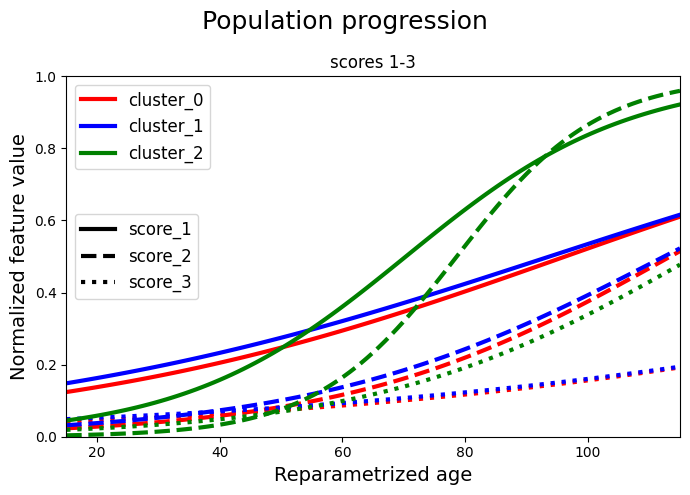

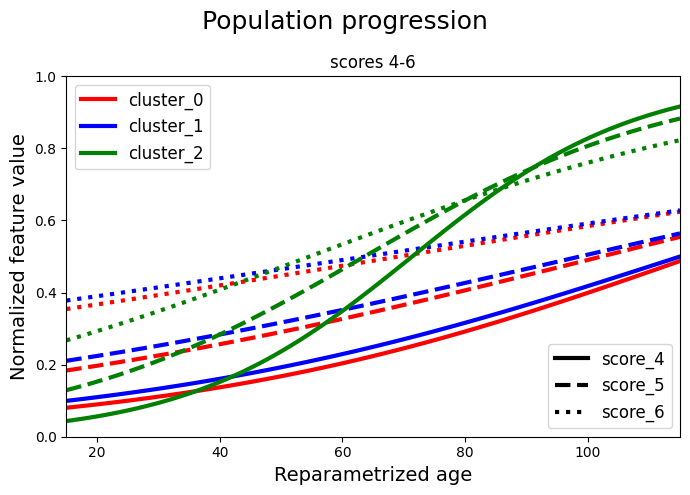

In [8]:
from matplotlib.lines import Line2D

timepoints = np.linspace(15, 115, 105)
values_0 = model.estimate({"average": timepoints}, ip_0)
values_1 = model.estimate({"average": timepoints}, ip_1)
values_2 = model.estimate({"average": timepoints}, ip_2)

# A. Scores 1-3

plt.figure(figsize=(7, 5))
plt.ylim(0, 1)
lines = [
    "-",
    "--",
    ":",
]
## cluster 0
for ls, name, val in zip(lines, model.features, values_0["average"][:, 0:3].T):
    plt.plot(timepoints, val, label=f"cluster_0_{name}", c="red", linewidth=3, ls=ls)

## cluster 1
for ls, name, val in zip(lines, model.features, values_1["average"][:, 0:3].T):
    plt.plot(timepoints, val, label=f"cluster_1_{name}", c="blue", linewidth=3, ls=ls)

## cluster 2
for ls, name, val in zip(lines, model.features, values_2["average"][:, 0:3].T):
    plt.plot(timepoints, val, label=f"cluster_2_{name}", c="green", linewidth=3, ls=ls)

## legends
cluster_legend = [
    Line2D([0], [0], color="red", linewidth=3, label="cluster_0"),
    Line2D([0], [0], color="blue", linewidth=3, label="cluster_1"),
    Line2D([0], [0], color="green", linewidth=3, label="cluster_2"),
]
legend1 = plt.legend(handles=cluster_legend, loc="upper left", prop={"size": 12})

color_legend = [
    Line2D([0], [0], linestyle=lines[0], color="black", linewidth=3, label="score_1"),
    Line2D([0], [0], linestyle=lines[1], color="black", linewidth=3, label="score_2"),
    Line2D([0], [0], linestyle=lines[2], color="black", linewidth=3, label="score_3"),
]
legend2 = plt.legend(
    handles=color_legend, loc="center left", title_fontsize=14, prop={"size": 12}
)

plt.gca().add_artist(legend1)

plt.xlim(min(timepoints), max(timepoints))
plt.xlabel("Reparametrized age", fontsize=14)
plt.ylabel("Normalized feature value", fontsize=14)
plt.title("scores 1-3")
plt.suptitle("Population progression", fontsize=18)
plt.tight_layout()
plt.show()

# B. Scores 4-6

plt.figure(figsize=(7, 5))
plt.ylim(0, 1)
lines = [
    "-",
    "--",
    ":",
]
## cluster 0
for ls, name, val in zip(lines, model.features, values_0["average"][:, 3:6].T):
    plt.plot(timepoints, val, label=f"cluster_0_{name}", c="red", linewidth=3, ls=ls)

## cluster 1
for ls, name, val in zip(lines, model.features, values_1["average"][:, 3:6].T):
    plt.plot(timepoints, val, label=f"cluster_1_{name}", c="blue", linewidth=3, ls=ls)

## cluster 2
for ls, name, val in zip(lines, model.features, values_2["average"][:, 3:6].T):
    plt.plot(timepoints, val, label=f"cluster_2_{name}", c="green", linewidth=3, ls=ls)

## legends
cluster_legend = [
    Line2D([0], [0], color="red", linewidth=3, label="cluster_0"),
    Line2D([0], [0], color="blue", linewidth=3, label="cluster_1"),
    Line2D([0], [0], color="green", linewidth=3, label="cluster_2"),
]
legend1 = plt.legend(handles=cluster_legend, loc="upper left", prop={"size": 12})

color_legend = [
    Line2D([0], [0], linestyle=lines[0], color="black", linewidth=3, label="score_4"),
    Line2D([0], [0], linestyle=lines[1], color="black", linewidth=3, label="score_5"),
    Line2D([0], [0], linestyle=lines[2], color="black", linewidth=3, label="score_6"),
]
legend2 = plt.legend(
    handles=color_legend, loc="lower right", title_fontsize=14, prop={"size": 12}
)

plt.gca().add_artist(legend1)

plt.xlim(min(timepoints), max(timepoints))
plt.xlabel("Reparametrized age", fontsize=14)
plt.ylabel("Normalized feature value", fontsize=14)
plt.title("scores 4-6")
plt.suptitle("Population progression", fontsize=18)
plt.tight_layout()
plt.show()